In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
file_path = '/content/drive/MyDrive/Mall_Customers.csv'
df = pd.read_csv(file_path)


Read the CSV file from the given path and store it as a DataFrame.

In [ ]:
print("First 5 rows:")
print(df.head())



First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


This prints the first 5 rows of the DataFrame df, allowing you to quickly preview the data and check its structure, column values, and sample entries.

In [ ]:


print("\nDataset Info:")
print(df.info())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


This displays a concise summary of the DataFrame, including the number of entries, column names, data types, and count of non-null values, which helps identify missing data

In [ ]:
def spending_category(score):
    if score <= 33:
        return 0   # Low
    elif score <= 66:
        return 1   # Medium
    else:
        return 2   # High

df['Spending_Category'] = df['Spending Score (1-100)'].apply(spending_category)

This part defines a function spending_category that classifies customers based on their spending score into three categories: Low (0), Medium (1), and High (2). It then applies this function to the Spending Score (1-100) column of the DataFrame df and creates a new column Spending_Category containing these categorical values.

In [ ]:
df = df.drop(columns=['CustomerID'])

# Convert Gender to numeric (Male=0, Female=1)
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})



CustomerID is just an identifier and has no effect on prediction, so we remove it.
Machine learning models work with numbers.Thats why we convert categorical Gender into numeric values.

In [ ]:

print(df.head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Spending_Category
0       0   19                  15                      39                  1
1       0   21                  15                      81                  2
2       1   20                  16                       6                  0
3       1   23                  16                      77                  2
4       1   31                  17                      40                  1


In [ ]:
# Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

KNN and clustering are distance-based algorithms.
Scaling ensures all features contribute equally.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


# KNN Classification
X = scaled_data
y = df['Spending_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("\n🔹 KNN Accuracy:", accuracy_score(y_test, y_pred))


# DBCAN Clustering

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)


# Gaussian Mixture Model
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)


# Evaluation for Clustering
print("\n--- Clustering Evaluation ---")


# DBSCAN
if len(set(dbscan_labels)) > 1:
    print("DBSCAN Silhouette:",
          silhouette_score(X, dbscan_labels))
    print("DBSCAN DB Index:",
          davies_bouldin_score(X, dbscan_labels))
else:
    print("DBSCAN formed only 1 cluster")

# GMM
print("GMM Silhouette:",
      silhouette_score(X, gmm_labels))
print("GMM DB Index:",
      davies_bouldin_score(X, gmm_labels))


# PCA for 2D Visualization

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

df['KNN_Class'] = knn.predict(X)
df['DBSCAN_Cluster'] = dbscan_labels
df['GMM_Cluster'] = gmm_labels



🔹 KNN Accuracy: 0.975

--- Clustering Evaluation ---
DBSCAN Silhouette: 0.00873999338209512
DBSCAN DB Index: 1.5064003276793247
GMM Silhouette: 0.25463308052011696
GMM DB Index: 1.6447472670443783


This code first performs KNN classification using the scaled dataset. The data is split into training and testing sets (80% training, 20% testing). The KNN model is trained with 5 neighbors, and predictions are made on the test data.

Next, DBSCAN clustering is applied to the entire dataset. It groups data points based on density using eps=0.5 and min_samples=5. After clustering, cluster labels are generated.

Then, a Gaussian Mixture Model (GMM) is applied with 3 components. It clusters the data assuming it comes from multiple Gaussian distributions.

For clustering evaluation, the code calculates Silhouette Score and Davies-Bouldin Index. These metrics measure how well the clusters are separated and how compact they are. If DBSCAN produces only one cluster, evaluation is skipped.

Finally, PCA (Principal Component Analysis) reduces the data to 2 dimensions for visualization. The PCA components are added to the dataframe, along with the predicted class (KNN) and cluster labels (DBSCAN and GMM), so they can be plotted and compared visually.

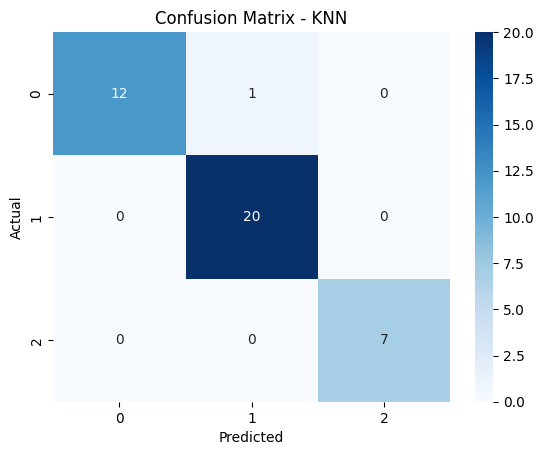

In [ ]:
#confusion matrix for KNN

import seaborn as sns
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

This code calculates the confusion matrix by comparing the actual test labels with the predicted labels from the KNN model. It then visualizes the matrix using a heatmap to clearly show correct and incorrect predictions. The numbers inside each cell represent how many samples were classified in each category. The X-axis shows predicted classes, and the Y-axis shows actual classes.

PCA Visualization


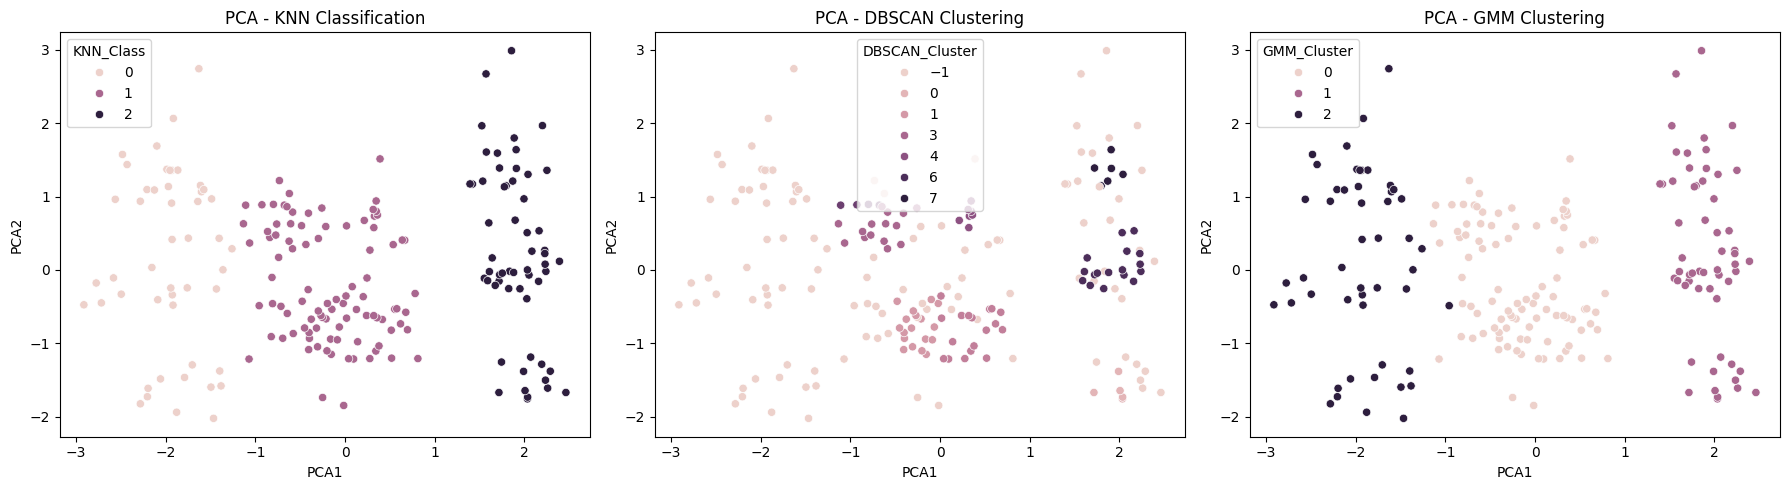

In [ ]:
plt.figure(figsize=(18,5))

# KNN
plt.subplot(1,3,1)
sns.scatterplot(x='PCA1', y='PCA2',
                hue='KNN_Class',
                data=df)
plt.title("PCA - KNN Classification")

# DBSCAN
plt.subplot(1,3,2)
sns.scatterplot(x='PCA1', y='PCA2',
                hue='DBSCAN_Cluster',
                data=df)
plt.title("PCA - DBSCAN Clustering")

# GMM
plt.subplot(1,3,3)
sns.scatterplot(x='PCA1', y='PCA2',
                hue='GMM_Cluster',
                data=df)
plt.title("PCA - GMM Clustering")

plt.tight_layout()
plt.show()


KNN-It helps visualize how KNN separates different classes in the reduced 2D feature space. If the classes are clearly separated by color, KNN performed well.

DBSCAN-It shows how DBSCAN identifies dense clusters and detects outliers. If isolated points have a different color (often noise), it means DBSCAN successfully detected anomalies.

GMM-This visualization shows how GMM forms soft clusters based on probability distributions. Clusters may look more elliptical compared to DBSCAN.